# Exploración del Dataset MPU6050

**Taller: Sensores inteligentes, IA en sistemas embebidos**

Este notebook explora el dataset de Kaggle `mpu6050-3-axis-acceleration-dataset`
antes de entrenar el modelo de clasificación de movimiento.

**¿Qué aprenderemos?**
- Cómo se ven los datos de aceleración en bruto
- Cómo difieren las clases de movimiento (caminar vs correr vs quieto)
- Por qué tiene sentido usar ventanas con features estadísticas
- Cuántas clases existen y si están balanceadas

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Añadir el directorio de scripts al path para importar feature_extractor
sys.path.append(str(Path('..') / 'scripts'))

plt.rcParams['figure.figsize'] = (12, 4)
plt.style.use('seaborn-v0_8-whitegrid')
print('Librerías cargadas OK')

Librerías cargadas OK


## 1. Carga del dataset

Asegúrate de haber corrido primero:
```bash
python scripts/01_prepare_data.py
```

In [2]:
# Intentar cargar el dataset limpio; si no existe, cargar el raw
cleaned_path = Path('../data/processed/cleaned_data.csv')
raw_path = list(Path('../data/raw').glob('*.csv'))

if cleaned_path.exists():
    df = pd.read_csv(cleaned_path)
    print(f'Cargado dataset limpio: {cleaned_path.name}')
elif raw_path:
    df = pd.read_csv(raw_path[0])
    print(f'Cargado dataset raw: {raw_path[0].name}')
    print('AVISO: Corre 01_prepare_data.py para obtener el dataset limpio')
else:
    raise FileNotFoundError(
        'No se encontró ningún CSV.\n'
        'Descarga el dataset de Kaggle y ponlo en ml/data/raw/'
    )

print(f'\nShape: {df.shape}')
print(f'Columnas: {list(df.columns)}')
df.head()

Cargado dataset limpio: cleaned_data.csv

Shape: (87411, 5)
Columnas: ['ax', 'ay', 'az', 'activity', 'magnitude']


,ax,ay,az,activity,magnitude
0,0.00,0.00,0.00,drinking,0.000000
1,9.20,1.67,1.84,drinking,9.529664
2,8.90,1.66,1.58,drinking,9.190320
3,8.96,1.78,1.65,drinking,9.282914
4,9.18,1.67,1.89,drinking,9.520158


## 2. Inspección básica

In [3]:
print('=== INFORMACIÓN GENERAL ===')
print(df.info())
print('\n=== ESTADÍSTICAS ===')
df.describe().round(4)

=== INFORMACIÓN GENERAL ===
<class 'pandas.DataFrame'>
RangeIndex: 87411 entries, 0 to 87410
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   ax         87411 non-null  float64
 1   ay         87411 non-null  float64
 2   az         87411 non-null  float64
 3   activity   87411 non-null  str    
 4   magnitude  87411 non-null  float64
dtypes: float64(4), str(1)
memory usage: 3.3 MB
None

=== ESTADÍSTICAS ===


,ax,ay,az,magnitude
count,87411.0000,87411.000,87411.0000,87411.0000
mean,7.8288,0.915,0.2450,10.1872
std,3.0031,4.280,4.2396,1.9286
min,-18.1400,-20.490,-26.2800,0.0000
25%,6.6600,-0.950,-2.0300,9.6637
50%,8.8300,0.400,1.3600,9.9352
75%,9.6800,2.190,2.9700,10.2314
max,30.7800,22.960,26.9300,39.6659


In [4]:
# Detectar columna de etiqueta (puede llamarse 'activity', 'label', 'class')
LABEL_COL = next(
    (c for c in df.columns if c.lower() in ['activity', 'label', 'class', 'target']),
    None
)

if LABEL_COL:
    print(f'Columna de etiqueta: {LABEL_COL}')
    print(f'\nClases y distribución:')
    print(df[LABEL_COL].value_counts())
else:
    print('No se detectó columna de etiqueta automáticamente.')
    print(f'Columnas disponibles: {list(df.columns)}')

Columna de etiqueta: activity

Clases y distribución:
activity
driving     29637
drinking    29624
throwing    28150
Name: count, dtype: int64


## 3. Distribución de clases

Verificamos si el dataset está balanceado.
Las clases muy desbalanceadas pueden sesgar el modelo.

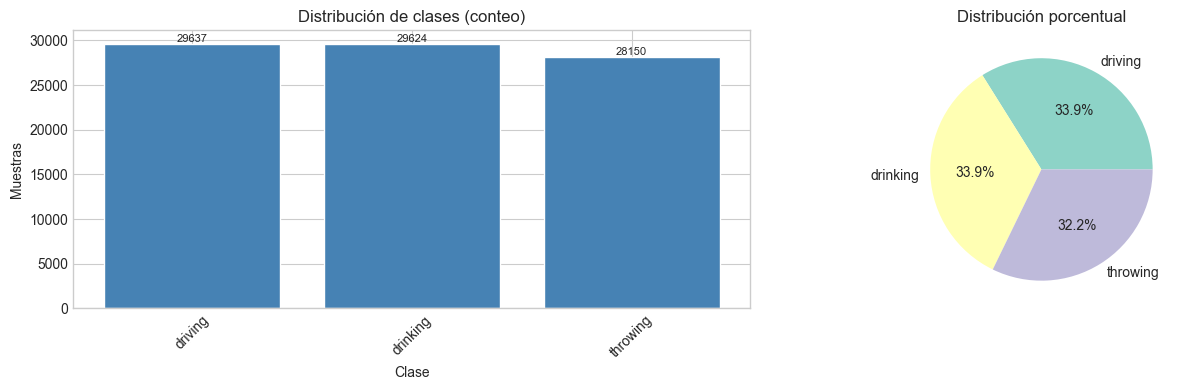


✓ Dataset balanceado (ratio max/min: 1.05x)


In [5]:
if LABEL_COL:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    # Barras de conteo
    counts = df[LABEL_COL].value_counts()
    axes[0].bar(counts.index, counts.values, color='steelblue', edgecolor='white')
    axes[0].set_title('Distribución de clases (conteo)')
    axes[0].set_xlabel('Clase')
    axes[0].set_ylabel('Muestras')
    axes[0].tick_params(axis='x', rotation=45)
    for bar, val in zip(axes[0].patches, counts.values):
        axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                     str(val), ha='center', va='bottom', fontsize=8)

    # Pie chart
    axes[1].pie(counts.values, labels=counts.index, autopct='%1.1f%%',
                colors=plt.cm.Set3.colors[:len(counts)])
    axes[1].set_title('Distribución porcentual')

    plt.tight_layout()
    plt.show()

    # Advertencia si hay desbalance severo
    max_ratio = counts.max() / counts.min()
    if max_ratio > 3:
        print(f'\n⚠ AVISO: Desbalance de clases detectado (ratio {max_ratio:.1f}x)')
        print('  El script 03_train.py usa class_weight="balanced" para compensarlo.')
    else:
        print(f'\n✓ Dataset balanceado (ratio max/min: {max_ratio:.2f}x)')

## 4. Visualización de señales crudas por clase

Esto muestra visualmente por qué las distintas actividades generan patrones diferentes.

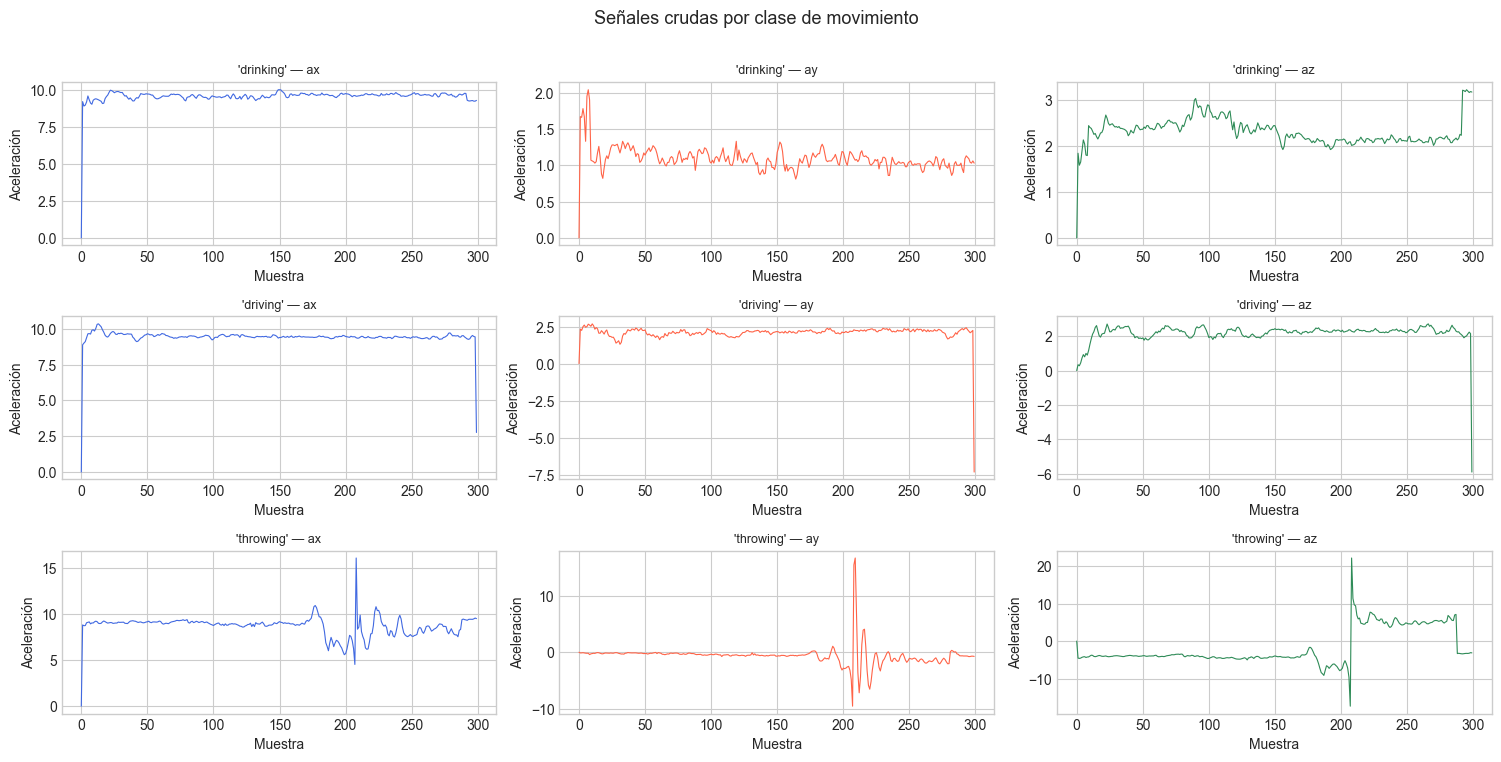

In [6]:
AXIS_COLS = [c for c in ['ax', 'ay', 'az'] if c in df.columns]
N_SAMPLES_TO_SHOW = 300  # muestras por clase en el gráfico

if LABEL_COL and AXIS_COLS:
    classes = df[LABEL_COL].unique()[:6]  # máximo 6 clases para no saturar
    n_classes = len(classes)
    n_axes = len(AXIS_COLS)

    fig, axes = plt.subplots(
        n_classes, n_axes,
        figsize=(5 * n_axes, 2.5 * n_classes),
        squeeze=False
    )

    colors = ['royalblue', 'tomato', 'seagreen']

    for row, label in enumerate(classes):
        subset = df[df[LABEL_COL] == label].head(N_SAMPLES_TO_SHOW)
        for col, (axis, color) in enumerate(zip(AXIS_COLS, colors)):
            axes[row][col].plot(subset[axis].values, color=color, linewidth=0.8)
            axes[row][col].set_title(f"'{label}' — {axis}", fontsize=9)
            axes[row][col].set_xlabel('Muestra')
            axes[row][col].set_ylabel('Aceleración')

    plt.suptitle('Señales crudas por clase de movimiento', fontsize=13, y=1.01)
    plt.tight_layout()
    plt.show()

## 5. Distribución de valores por eje

Los histogramas muestran el rango de valores típicos.
Útil para detectar outliers y entender la escala del sensor.

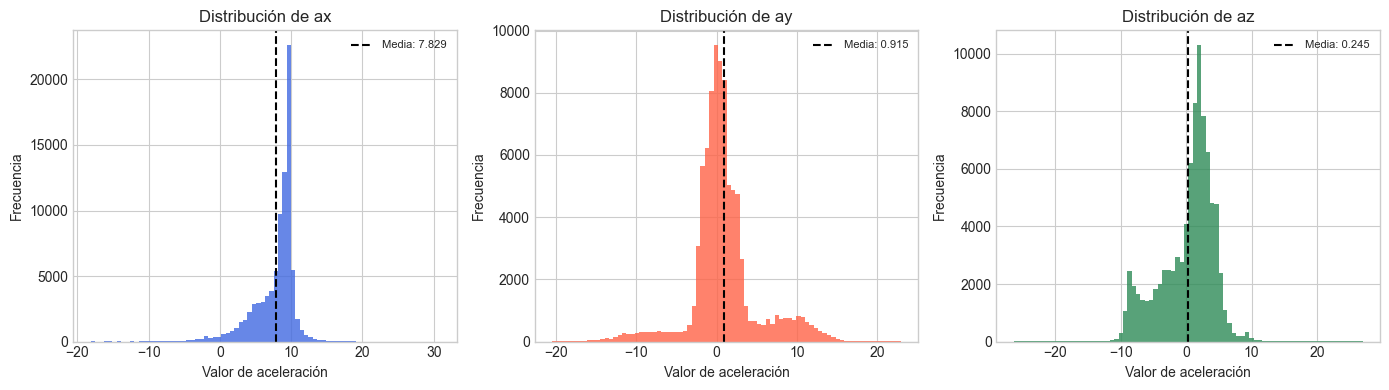

In [7]:
if AXIS_COLS:
    fig, axes_plots = plt.subplots(1, len(AXIS_COLS), figsize=(14, 4))
    if len(AXIS_COLS) == 1:
        axes_plots = [axes_plots]

    colors = ['royalblue', 'tomato', 'seagreen']
    for ax_plot, col, color in zip(axes_plots, AXIS_COLS, colors):
        ax_plot.hist(df[col], bins=80, color=color, alpha=0.8, edgecolor='none')
        ax_plot.set_title(f'Distribución de {col}')
        ax_plot.set_xlabel('Valor de aceleración')
        ax_plot.set_ylabel('Frecuencia')
        ax_plot.axvline(df[col].mean(), color='black', linestyle='--',
                        linewidth=1.5, label=f'Media: {df[col].mean():.3f}')
        ax_plot.legend(fontsize=8)

    plt.tight_layout()
    plt.show()

## 6. Correlación entre features estadísticas

Una vez extraídas las features, verificamos si hay correlaciones altas
que podrían indicar redundancia.

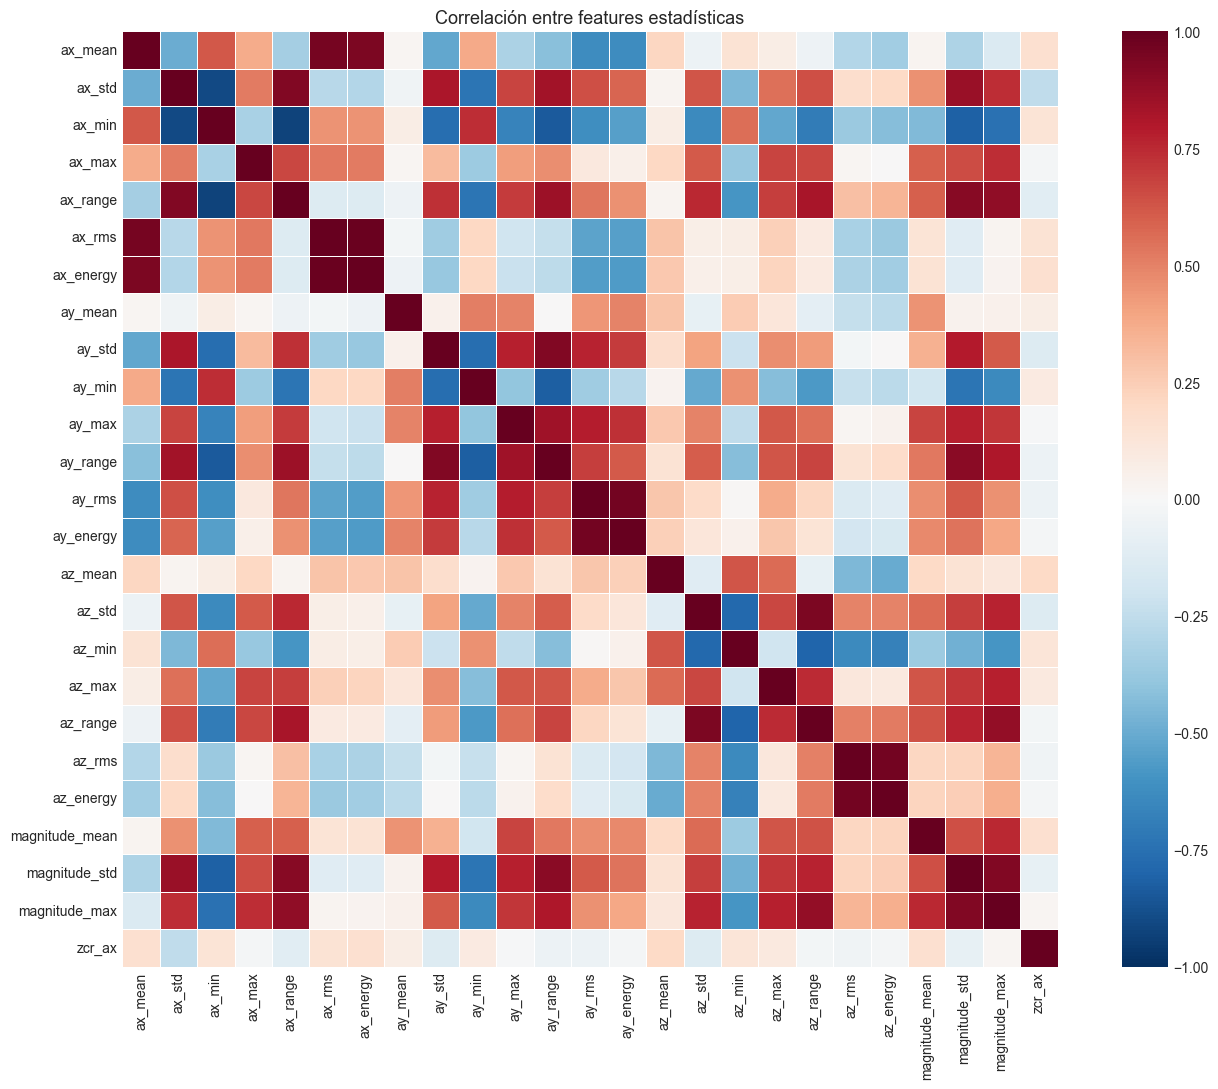

Total features: 25
Total ventanas: 3,492


In [8]:
features_path = Path('../data/processed/features_dataset.csv')

if features_path.exists():
    df_feat = pd.read_csv(features_path)
    feature_cols = [c for c in df_feat.columns if c != LABEL_COL]

    # Mapa de correlación
    corr = df_feat[feature_cols].corr()

    fig, ax = plt.subplots(figsize=(14, 11))
    sns.heatmap(
        corr, ax=ax,
        cmap='RdBu_r', center=0,
        vmin=-1, vmax=1,
        annot=False, linewidths=0.5,
        square=True
    )
    ax.set_title('Correlación entre features estadísticas', fontsize=13)
    plt.tight_layout()
    plt.show()

    print(f'Total features: {len(feature_cols)}')
    print(f'Total ventanas: {len(df_feat):,}')
else:
    print('Ejecuta primero: python scripts/02_extract_features.py')

## 7. Separabilidad de clases

Boxplots de las features más informativas, separados por clase.

C:\Users\Public\Documents\Wondershare\CreatorTemp\ipykernel_14068\1120685032.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax_p.boxplot(groups, labels=df_feat[LABEL_COL].unique(), showfliers=False)
C:\Users\Public\Documents\Wondershare\CreatorTemp\ipykernel_14068\1120685032.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax_p.boxplot(groups, labels=df_feat[LABEL_COL].unique(), showfliers=False)
C:\Users\Public\Documents\Wondershare\CreatorTemp\ipykernel_14068\1120685032.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax_p.boxplot(groups, labels=df_feat[LABEL_COL].unique(), showfliers=False)
C:\Users\P

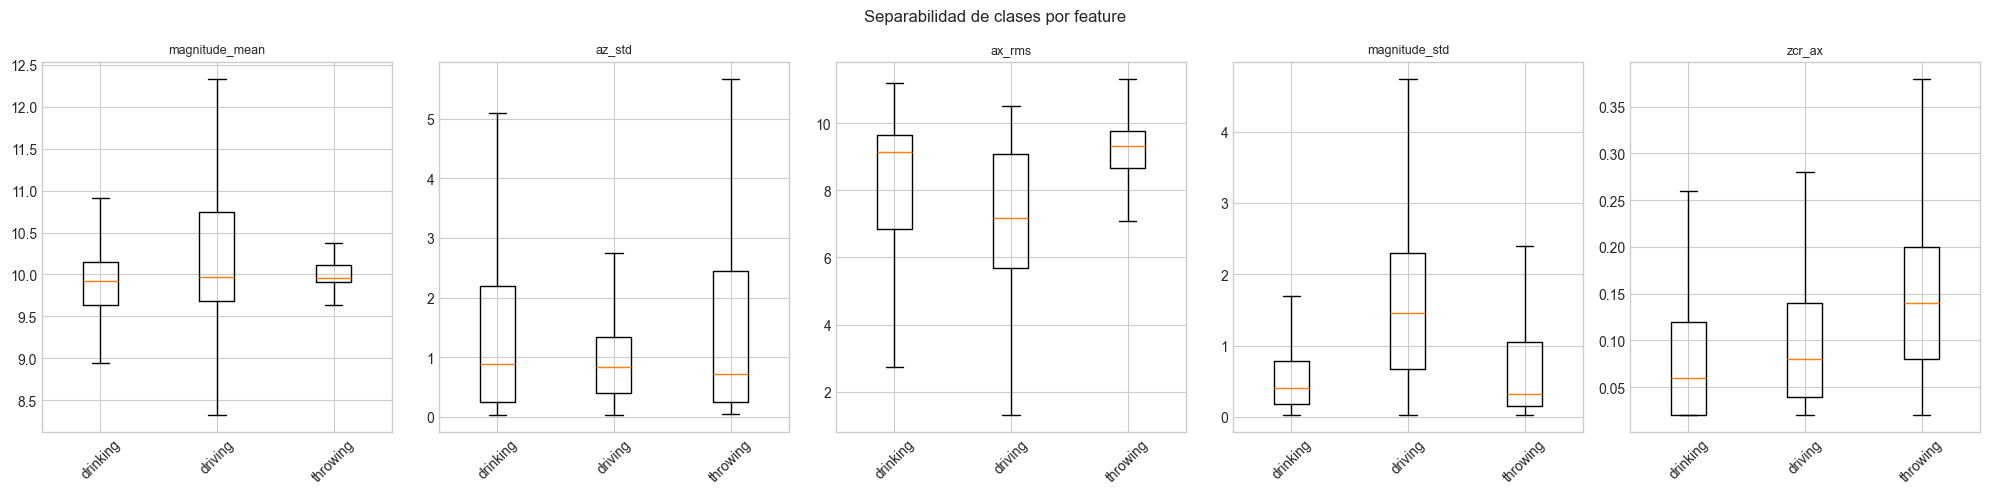

Las features con boxplots bien separados son las más útiles para el modelo.


In [9]:
if features_path.exists():
    df_feat = pd.read_csv(features_path)
    # Mostrar las features más importantes visualmente
    key_features = ['magnitude_mean', 'az_std', 'ax_rms', 'magnitude_std', 'zcr_ax']
    key_features = [f for f in key_features if f in df_feat.columns]

    if key_features and LABEL_COL in df_feat.columns:
        fig, axes_p = plt.subplots(1, len(key_features),
                                    figsize=(4 * len(key_features), 5))
        if len(key_features) == 1:
            axes_p = [axes_p]

        for ax_p, feat in zip(axes_p, key_features):
            groups = [df_feat[df_feat[LABEL_COL] == lbl][feat].values
                      for lbl in df_feat[LABEL_COL].unique()]
            ax_p.boxplot(groups, labels=df_feat[LABEL_COL].unique(), showfliers=False)
            ax_p.set_title(feat, fontsize=9)
            ax_p.tick_params(axis='x', rotation=45)

        plt.suptitle('Separabilidad de clases por feature', fontsize=12)
        plt.tight_layout()
        plt.show()
        print('Las features con boxplots bien separados son las más útiles para el modelo.')

## 8. Conclusiones del EDA

Completa esta celda con tus observaciones después de explorar el dataset:

- **Clases detectadas**: ...
- **Balance de clases**: ...
- **Rango de valores de aceleración**: ...
- **Features más separables visualmente**: ...
- **Observaciones adicionales**: ...